In [1]:
# Imports required libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.model_selection import GroupShuffleSplit

In [2]:
# Load dataset and defines features
df = pd.read_csv('Model_Ready_Features.csv')
all_features = ['maxNdvi', 'maxMsavi', 'maxMndwi', 'baseNdvi', 'baseMsavi', 'ampNdvi', 
                'B1', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'slope']
X = df[all_features]
groups = df['poly_id']

y = (df['class'].astype(str) == '1').astype(int)

# Split data 
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

In [3]:
# Train the model
rf_model = RandomForestClassifier(n_estimators=250, class_weight='balanced', random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)

In [4]:
# Prints text evaluation metrics
print(f"Strict Spatial Accuracy: {accuracy_score(y_test, y_pred):.2%}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Non-Crop', 'Crop']))

Strict Spatial Accuracy: 83.91%

Classification Report:
              precision    recall  f1-score   support

    Non-Crop       0.88      0.86      0.87       390
        Crop       0.78      0.81      0.80       244

    accuracy                           0.84       634
   macro avg       0.83      0.83      0.83       634
weighted avg       0.84      0.84      0.84       634



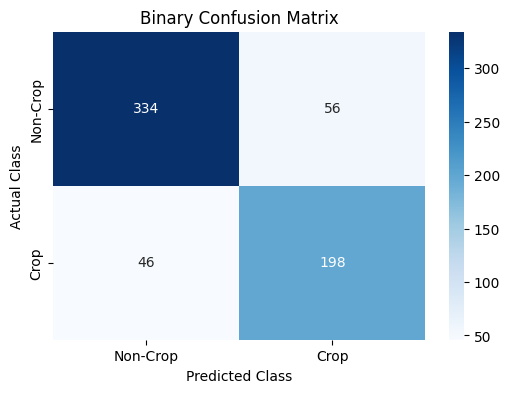

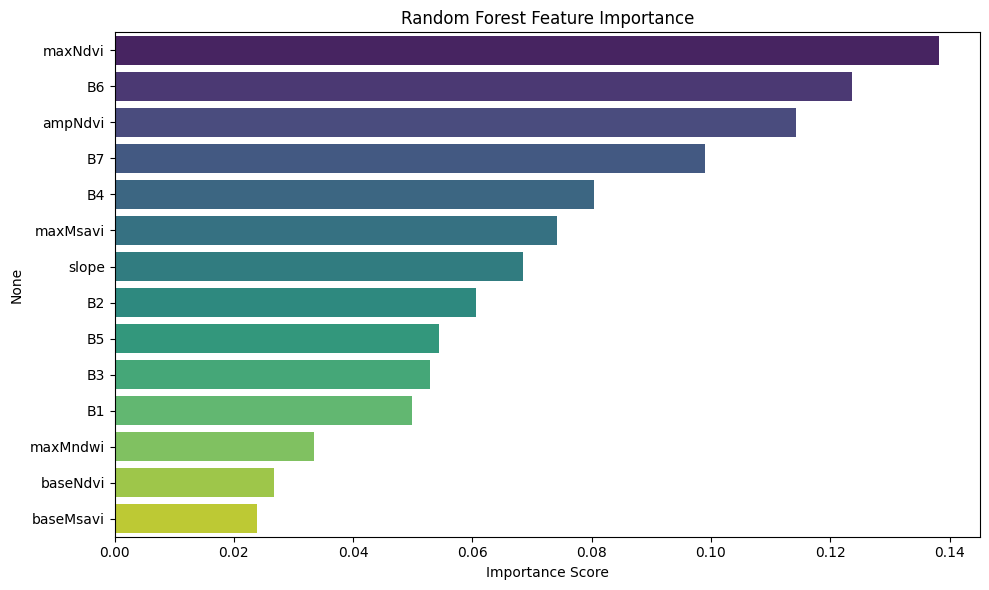

In [5]:
# Plot confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Non-Crop', 'Crop'], yticklabels=['Non-Crop', 'Crop'])
plt.title('Binary Confusion Matrix')
plt.ylabel('Actual Class')
plt.xlabel('Predicted Class')
plt.show()

# Plot feature importance
importances = pd.Series(rf_model.feature_importances_, index=all_features).sort_values(ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x=importances, y=importances.index, hue=importances.index, palette='viridis', legend=False)
plt.title('Random Forest Feature Importance')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()